# EDA — Dataset B: MentalChat16K (ShenLab)

| Item | Detail |
|---|---|
| **Source** | `ShenLab/MentalChat16K` (MIT; citation requested: Xu et al., arXiv:2503.13509) |
| **Raw file** | `../data/mh_conversation/raw/dataset_B_mentalchat16k.json` (JSONL) + the two source CSVs for provenance |
| **Fields** | `instruction` (fixed boilerplate — dropped), `input` (patient) → `output` (counselor) |
| **Composition** | ~10K synthetic GPT-3.5 dialogues + ~6K paraphrased caregiver-interview transcripts |
| **Split** | 70/20/10 grouped by user text, seed 42 — the prior study's row-level split leaked ~10 identical inputs across splits |

In [1]:
# Cell 1 — Imports + load raw JSONL
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tiktoken

import ft_utils

DKEY = "mentalchat16k"
C_SYN = "#4477AA"      # blue   — synthetic rows
C_ITV = "#EE7733"      # orange — interview rows
C_WORDS = "#AA3377"    # single-series accent (not tied to a source)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

raw = pd.read_json(ft_utils.RAW_DIR / ft_utils.CFG["datasets"][DKEY]["raw_filename"], lines=True)
print(f"Shape (raw): {raw.shape}")
print(f"Columns: {list(raw.columns)}")

# The instruction column is one fixed boilerplate string on every row — no
# per-row signal, and it would duplicate our own system prompt, so it is NOT
# mapped into the user turn (config: use_instruction_field: false).
print(f"\nUnique instruction values: {raw['instruction'].nunique()}")
print(f"Instruction text: {raw['instruction'].iloc[0][:160]!r}")

Shape (raw): (16084, 3)
Columns: ['instruction', 'input', 'output']

Unique instruction values: 1
Instruction text: "You are a helpful mental health counselling assistant, please answer the mental health questions based on the patient's description. \nThe assistant gives helpfu"


In [2]:
# Cell 2 — Missing/empty values and duplicates
inp = raw["input"].fillna("").astype(str).str.strip()
out = raw["output"].fillna("").astype(str).str.strip()
print(f"Empty input rows:  {(inp == '').sum()}")
print(f"Empty output rows: {(out == '').sum()}")
print(f"Exact duplicate (input, output) rows: {raw.duplicated(subset=['input', 'output']).sum()}")
print(f"Duplicate inputs (same patient text, possibly different answers): "
      f"{raw.duplicated(subset=['input']).sum()}")

df = ft_utils.load_raw(DKEY)   # strip -> drop empty -> dedupe
print(f"\nCleaned shape: {df.shape}  (removed {len(raw) - len(df)} rows)")

Empty input rows:  27
Empty output rows: 0
Exact duplicate (input, output) rows: 77
Duplicate inputs (same patient text, possibly different answers): 227

Cleaned shape: (15978, 2)  (removed 106 rows)


source
synthetic    9747
interview    6231
Name: count, dtype: int64


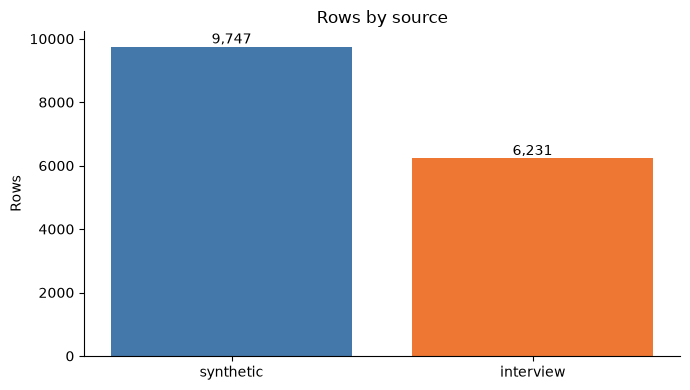

In [3]:
# Cell 3 — Provenance: synthetic GPT-3.5 dialogues vs caregiver interviews
# Exact (input, output) content match against the two source CSVs.
df = ft_utils.add_provenance(df, DKEY)
counts = df["source"].value_counts()
print(counts)

colors = {"synthetic": C_SYN, "interview": C_ITV}
plt.figure(figsize=(7, 4))
bars = plt.bar(counts.index, counts.values,
               color=[colors.get(s, "#999999") for s in counts.index])
plt.bar_label(bars, fmt="{:,.0f}")
plt.title("Rows by source")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 — One sample from each source
for src in ("synthetic", "interview"):
    row = df[df["source"] == src].iloc[0]
    print(f"--- {src} ---")
    print(f"INPUT:  {row['input'][:300]}...")
    print(f"OUTPUT: {row['output'][:300]}...")
    print()

--- synthetic ---
INPUT:  I think I might be developing a substance abuse problem. Lately, I've been relying on alcohol as a way to cope with my emotions and escape from reality. It started off as occasional drinking, but now it has become a daily habit. I'm worried about the impact it's having on my physical and mental well...
OUTPUT: I'm really glad that you reached out and shared what you've been going through. It takes a lot of courage to acknowledge and address these concerns. I can understand how relying on alcohol as a coping mechanism might feel like an escape from reality, but it's important to remember that there are hea...

--- interview ---
INPUT:  I've been struggling with my mental health for a while now, and I can't seem to find a way to cope with it. I've tried visualization, positive thinking, and even medication, but nothing seems to work. I've been feeling lost and helpless, and I don't know what to do next. My mind is a whirlwind of th...
OUTPUT: I understand that y

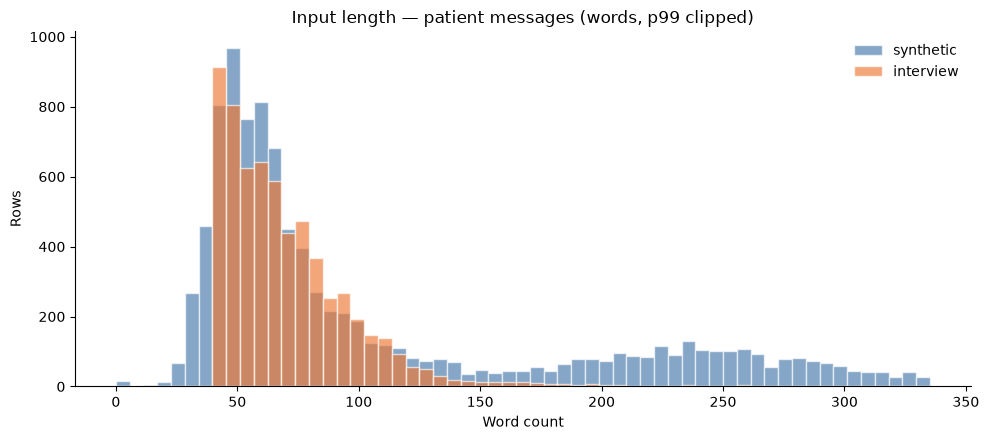

Median input words by source:
source
interview    64.0
synthetic    69.0
Name: input_words, dtype: float64


In [5]:
# Cell 5 — Input length by source (word count)
df["input_words"] = df["input"].str.split().str.len()
df["output_words"] = df["output"].str.split().str.len()

plt.figure(figsize=(10, 4.5))
bins = np.linspace(0, df["input_words"].quantile(0.99), 60)   # clip top-1% tail
for src, color in [("synthetic", C_SYN), ("interview", C_ITV)]:
    plt.hist(df.loc[df["source"] == src, "input_words"], bins=bins,
             alpha=0.65, color=color, edgecolor="white", label=src)
plt.title("Input length — patient messages (words, p99 clipped)")
plt.xlabel("Word count")
plt.ylabel("Rows")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
print("Median input words by source:")
print(df.groupby("source")["input_words"].median())

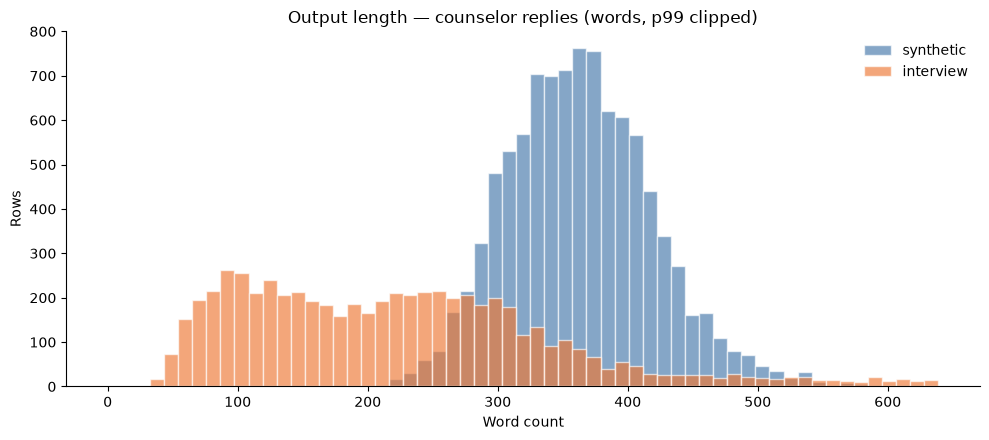

Median output words by source:
source
interview    216.0
synthetic    361.0
Name: output_words, dtype: float64


In [6]:
# Cell 6 — Output length by source (word count)
plt.figure(figsize=(10, 4.5))
bins = np.linspace(0, df["output_words"].quantile(0.99), 60)
for src, color in [("synthetic", C_SYN), ("interview", C_ITV)]:
    plt.hist(df.loc[df["source"] == src, "output_words"], bins=bins,
             alpha=0.65, color=color, edgecolor="white", label=src)
plt.title("Output length — counselor replies (words, p99 clipped)")
plt.xlabel("Word count")
plt.ylabel("Rows")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
print("Median output words by source:")
print(df.groupby("source")["output_words"].median())

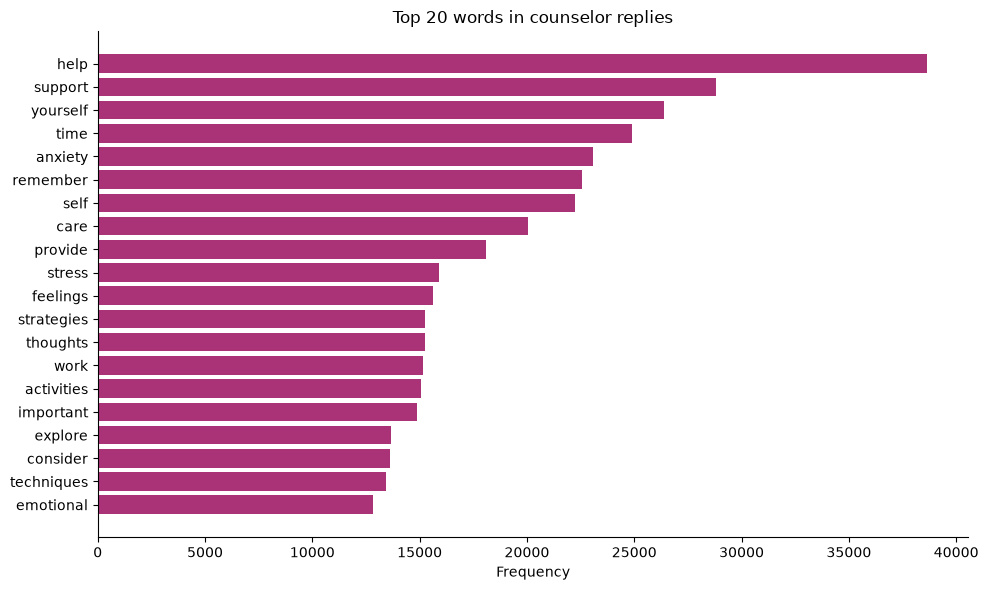

In [7]:
stopwords = {"the", "a", "an", "is", "are", "was", "were", "be", "been", "being",
             "have", "has", "had", "do", "does", "did", "will", "would", "could",
             "should", "may", "might", "shall", "can", "need", "dare", "to", "of",
             "in", "for", "on", "with", "at", "by", "from", "as", "into", "through",
             "during", "before", "after", "and", "but", "or", "nor", "not", "so",
             "yet", "both", "either", "neither", "each", "every", "all", "any",
             "few", "more", "most", "other", "some", "such", "no", "only", "own",
             "same", "than", "too", "very", "just", "because", "if", "when", "where",
             "how", "what", "which", "who", "whom", "this", "that", "these", "those",
             "i", "me", "my", "myself", "we", "our", "ours", "you", "your", "yours",
             "he", "him", "his", "she", "her", "hers", "it", "its", "they", "them",
             "their", "theirs", "about", "up", "out", "also", "like", "well", "even"}

# Cell 7 — Top 20 words in counselor replies (excl. stopwords)
words = []
for text in df["output"]:
    words.extend(w for w in re.findall(r"[a-z]+", text.lower())
                 if w not in stopwords and len(w) > 2)
top20 = Counter(words).most_common(20)
labels, counts = zip(*top20)

plt.figure(figsize=(10, 6))
plt.barh(list(reversed(labels)), list(reversed(counts)), color=C_WORDS)
plt.title("Top 20 words in counselor replies")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [8]:
# Cell 8 — Token statistics vs the 1024-token training window
enc = tiktoken.get_encoding("cl100k_base")  # approximation; the real tokenizers differ slightly
in_tok = df["input"].map(lambda t: len(enc.encode(t)))
out_tok = df["output"].map(lambda t: len(enc.encode(t)))
sys_tok = len(enc.encode(ft_utils.SYSTEM_PROMPT))
total = in_tok + out_tok + sys_tok + 20  # +20 ~ chat-template scaffolding

max_len = ft_utils.CFG["training"]["max_seq_length"]
print(f"Input tokens:  mean {in_tok.mean():.0f} | median {in_tok.median():.0f} | max {in_tok.max()}")
print(f"Output tokens: mean {out_tok.mean():.0f} | median {out_tok.median():.0f} | max {out_tok.max()}")
print(f"Full example (system+input+output+template): median {total.median():.0f} | "
      f"p95 {total.quantile(0.95):.0f} | max {total.max()}")
print(f"Examples fitting in max_seq_length={max_len}: {(total <= max_len).mean() * 100:.1f}%")
print("\nMedian output tokens by source:")
print(out_tok.groupby(df["source"]).median())

Input tokens:  mean 112 | median 78 | max 3155
Output tokens: mean 369 | median 385 | max 2174
Full example (system+input+output+template): median 541 | p95 890 | max 3950
Examples fitting in max_seq_length=1024: 98.7%

Median output tokens by source:
source
interview    254.0
synthetic    424.0
Name: output, dtype: float64


In [9]:
# Cell 9 — Grouped 70/20/10 split (cached to data/.../processed/mentalchat16k/)
# Some patient texts repeat with different counselor answers; grouping by user
# text keeps each one inside a single split (~99% of groups are singletons,
# so ratios stay ~70/20/10).
train_df, val_df, test_df = ft_utils.load_and_split(DKEY)
n = len(train_df) + len(val_df) + len(test_df)
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(part):6,} rows ({len(part) / n * 100:.1f}%) | "
          f"unique inputs: {part['input'].nunique():,}")

tr, va, te = set(train_df["input"]), set(val_df["input"]), set(test_df["input"])
print(f"\nLeakage check — shared inputs across splits: "
      f"train-val={len(tr & va)}, train-test={len(tr & te)}, val-test={len(va & te)}")
assert not (tr & va) and not (tr & te) and not (va & te), "user-text leakage across splits!"
print("OK: no patient text appears in more than one split.")

[mentalchat16k] saved splits -> C:\Users\laoli\OneDrive\Desktop\MultiAgent2\data\mh_conversation\processed\mentalchat16k (train 11185, val 3196, test 1597)
train: 11,185 rows (70.0%) | unique inputs: 11,098
val  :  3,196 rows (20.0%) | unique inputs: 3,167
test :  1,597 rows (10.0%) | unique inputs: 1,591

Leakage check — shared inputs across splits: train-val=0, train-test=0, val-test=0
OK: no patient text appears in more than one split.


## Summary

| Metric | Value |
|---|---|
| Raw rows | 16,084 |
| Sources | ~10K synthetic GPT-3.5 + ~6K paraphrased caregiver interviews (100% provenance match) |
| `instruction` column | one constant boilerplate string → dropped |
| Cleaned rows | *(see Cell 2)* |
| Split | 70/20/10 **grouped by patient text**, seed 42 |

**Observations**

1. The dataset is two populations in one file: synthetic dialogues and caregiver-interview paraphrases differ visibly in input and output length (Cells 5–6) — worth remembering when interpreting per-model results.
2. The constant `instruction` column carries no per-row signal and would duplicate our system prompt, so only `input` → `output` is used (config: `use_instruction_field: false`).
3. Cell 8 shows the share of full formatted examples fitting in the 1024-token window; long interview replies dominate the tail.
4. The grouped split fixes the ~10-input leakage the prior row-level split had, at negligible cost to the ratios. Splits are cached under `data/mh_conversation/processed/mentalchat16k/` and reused verbatim by `train.ipynb`.